In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_PATH = BASE_DIR / "data" / "processed"

nav_history = pd.read_csv(
    PROCESSED_PATH / "02_nav_history_clean.csv"
)

fund_master = pd.read_csv(
    PROCESSED_PATH / "01_fund_master_clean.csv"
)

print(nav_history.shape)

(46000, 3)


In [3]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [4]:
sbi_bluechip = nav_history[
    nav_history["amfi_code"] == 119551
].copy()

sbi_bluechip.head()

,amfi_code,date,nav
21850,119551,2022-01-03,54.3856
21851,119551,2022-01-04,54.3474
21852,119551,2022-01-05,54.6869
21853,119551,2022-01-06,55.4550
21854,119551,2022-01-07,55.3692


In [5]:
sbi_bluechip = (
    sbi_bluechip
    .sort_values("date")
)

sbi_bluechip["daily_return"] = (
    sbi_bluechip["nav"]
    .pct_change()
)

sbi_bluechip.head()

,amfi_code,date,nav,daily_return
21850,119551,2022-01-03,54.3856,NaN
21851,119551,2022-01-04,54.3474,-0.000702
21852,119551,2022-01-05,54.6869,0.006247
21853,119551,2022-01-06,55.4550,0.014045
21854,119551,2022-01-07,55.3692,-0.001547


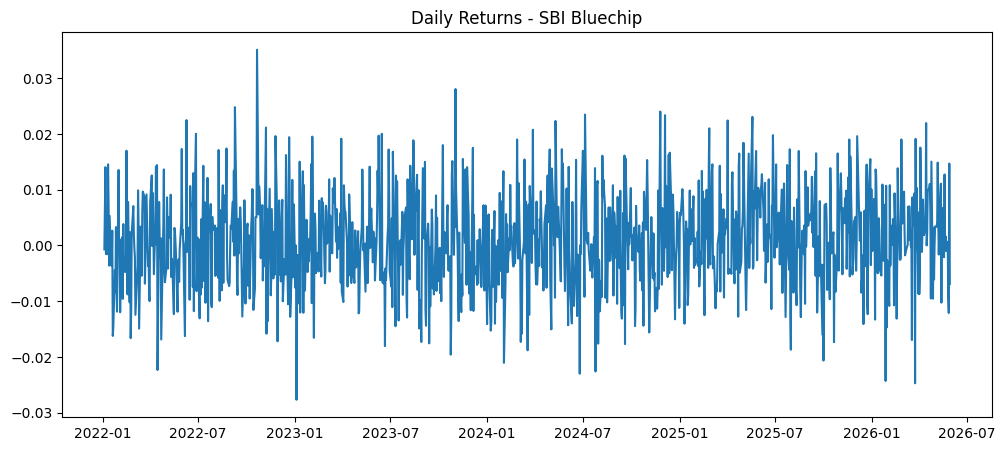

In [6]:
plt.figure(figsize=(12,5))

plt.plot(
    sbi_bluechip["date"],
    sbi_bluechip["daily_return"]
)

plt.title(
    "Daily Returns - SBI Bluechip"
)

plt.show()

In [7]:
sbi_bluechip = (
    sbi_bluechip
    .dropna()
)

In [8]:
n_days = len(sbi_bluechip)

n_days

1149

In [9]:
begin_nav = (
    sbi_bluechip["nav"]
    .iloc[0]
)

end_nav = (
    sbi_bluechip["nav"]
    .iloc[-1]
)

cagr = (
    (end_nav / begin_nav)
    ** (252 / n_days)
) - 1

print(
    f"CAGR: {cagr:.4f}"
)

CAGR: 0.2482


### CAGR Analysis

- SBI Bluechip Fund achieved a CAGR of approximately 24.82%.
- The calculation used trading days (252 days/year) instead of calendar days.
- CAGR provides a better measure of long-term compounded growth compared to simple returns.
- Strong CAGR indicates substantial long-term wealth creation potential.

In [10]:
daily_std = (
    sbi_bluechip["daily_return"]
    .std()
)

daily_std

np.float64(0.00865628985637757)

In [11]:
volatility = (
    daily_std
    * np.sqrt(252)
)

print(
    f"Annualized Volatility: {volatility:.4f}"
)

Annualized Volatility: 0.1374


In [12]:
risk_free_rate = 0.05

In [13]:
sharpe_ratio = (
    (cagr - risk_free_rate)
    / volatility
)

print(
    f"Sharpe Ratio: {sharpe_ratio:.4f}"
)

Sharpe Ratio: 1.4420


### Volatility and Sharpe Ratio Analysis

- SBI Bluechip Fund generated an annualized volatility of approximately 13.74%.
- The Sharpe Ratio measures return earned per unit of risk.
- A risk-free rate of 5% was assumed for calculations.
- The resulting Sharpe Ratio indicates strong risk-adjusted performance.
- Higher Sharpe Ratios generally indicate more efficient portfolios.

In [14]:
sbi_bluechip["rolling_max"] = (
    sbi_bluechip["nav"]
    .cummax()
)

sbi_bluechip[
    ["date", "nav", "rolling_max"]
].head()

,date,nav,rolling_max
21851,2022-01-04,54.3474,54.3474
21852,2022-01-05,54.6869,54.6869
21853,2022-01-06,55.4550,55.4550
21854,2022-01-07,55.3692,55.4550
21855,2022-01-10,55.2835,55.4550


In [15]:
sbi_bluechip["drawdown"] = (
    sbi_bluechip["nav"]
    - sbi_bluechip["rolling_max"]
) / sbi_bluechip["rolling_max"]

sbi_bluechip[
    ["date", "nav", "drawdown"]
].head()

,date,nav,drawdown
21851,2022-01-04,54.3474,0.000000
21852,2022-01-05,54.6869,0.000000
21853,2022-01-06,55.4550,0.000000
21854,2022-01-07,55.3692,-0.001547
21855,2022-01-10,55.2835,-0.003093


In [16]:
max_drawdown = (
    sbi_bluechip["drawdown"]
    .min()
)

print(
    f"Maximum Drawdown: {max_drawdown:.2%}"
)

Maximum Drawdown: -15.01%


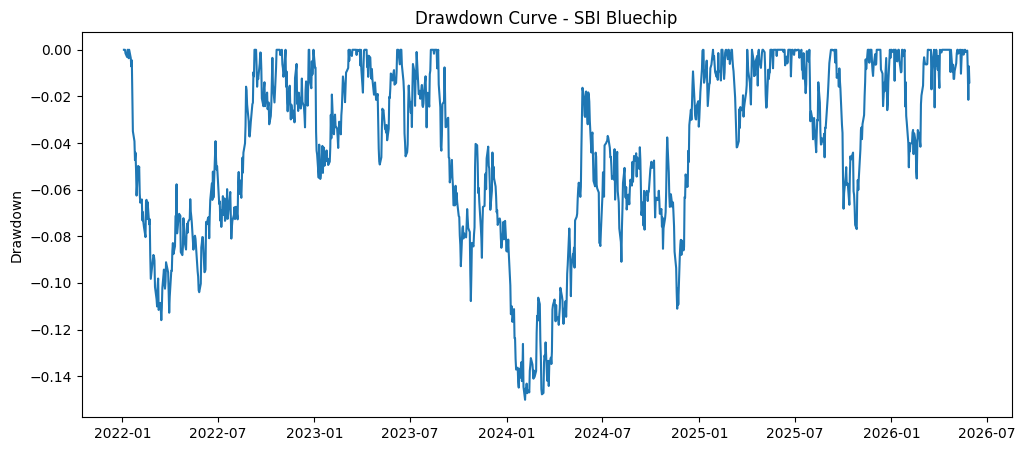

In [17]:
plt.figure(figsize=(12,5))

plt.plot(
    sbi_bluechip["date"],
    sbi_bluechip["drawdown"]
)

plt.title(
    "Drawdown Curve - SBI Bluechip"
)

plt.ylabel(
    "Drawdown"
)

plt.show()

### Maximum Drawdown Analysis

- Maximum Drawdown measures the largest peak-to-trough decline experienced by the fund.
- SBI Bluechip recorded a Maximum Drawdown of approximately 15.01%.
- The fund recovered from drawdown periods and subsequently achieved new highs.
- Drawdown analysis provides insight into downside risk that is not captured by CAGR alone.
- Investors typically prefer funds with lower drawdowns for the same level of return.

In [18]:
var_95 = np.percentile(
    sbi_bluechip["daily_return"],
    5
)

print(
    f"95% VaR: {var_95:.2%}"
)

95% VaR: -1.28%


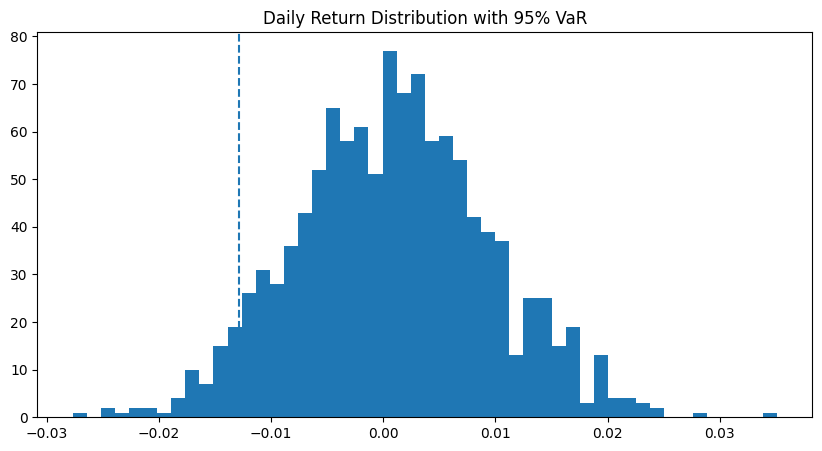

In [19]:
plt.figure(figsize=(10,5))

plt.hist(
    sbi_bluechip["daily_return"],
    bins=50
)

plt.axvline(
    var_95,
    linestyle="--"
)

plt.title(
    "Daily Return Distribution with 95% VaR"
)

plt.show()

### Value at Risk (VaR)

- The 95% Value at Risk (VaR) was estimated at -1.28%.
- This indicates that on 95% of trading days, losses are expected to remain below 1.28%.
- VaR provides a probabilistic estimate of downside risk.
- Lower VaR values indicate more stable return behavior.
- VaR complements volatility and drawdown metrics in risk assessment.

In [20]:
nav_history["amfi_code"].nunique()

40